In [17]:
import numpy as np
import pandas as pd
from matplotlib import pylab as plt
metadata_file = 'Metadata_icefront.txt'
df_info = pd.read_csv(metadata_file)                 


In [18]:
df_maxbmb =pd.read_csv('tables/prmse_recalc_groundingline_linear_meltsensetivity_from_BMB_max.csv')
df_maxbmb_2k =pd.read_csv('tables/prmse_recalc_groundingline_linear_meltsensetivity_from_BMB_max_TFuntil2K.csv')
df_maxbmb_2100 =pd.read_csv('tables/prmse_recalc_groundingline_linear_meltsensetivity_from_BMB_max_time2100.csv')
#                                     prmse_recalc_groundingline_linear_meltsensetivity_from_BMB_max_time2100
df_ms_2100 = pd.read_csv('./tables/linear_meltsensetivity_groundingline_from_BMB_max_time2100.csv')
df_ms_n_2100 = pd.read_csv('./tables/linear_meltsensetivity_groundingline_from_BMB_max_intercept_time2100.csv')
df_ms_2K = pd.read_csv('./tables/linear_meltsensetivity_groundingline_from_BMB_max_TFuntil2K.csv')
df_ms_n_2K = pd.read_csv('./tables/linear_meltsensetivity_groundingline_from_BMB_max_intercept_TFuntil2K.csv')

df_ms_o = pd.read_csv('./tables/linear_meltsensetivity_groundingline_from_BMB_max.csv')
df_ms_n_o = pd.read_csv('./tables/linear_meltsensetivity_groundingline_from_BMB_max_intercept.csv')



df_ms_all=[df_ms_o ,df_ms_2100,df_ms_2K]
df_ms_n_all=[df_ms_n_o ,df_ms_n_2100,df_ms_n_2K]

for df_ms in df_ms_all:
    df_ms['WestAntarctica'] = df_ms['region_1']
    df_ms['EastAntarctica'] = df_ms['region_2']
    df_ms['Peninsula'] = df_ms['region_3']
for df_ms_n in df_ms_n_all:    
    df_ms_n['WestAntarctica'] = df_ms_n['region_1']
    df_ms_n['EastAntarctica'] = df_ms_n['region_2']
    df_ms_n['Peninsula'] = df_ms_n['region_3']



# df_maxbmb_lc =pd.read_csv('tables/rmse_recalc_linear_meltsensetivity_from_BMB_max_lincomb.csv')
# df_maxbmb_2k_lc =pd.read_csv('tables/rmse_recalc_linear_meltsensetivity_from_BMB_max_TFuntil2K_lincomb.csv')
# df_maxbmb_2100_lc =pd.read_csv('tables/rmse_recalc_linear_meltsensetivity_from_BMB_max_time2100_lincomb.csv')
df_best = df_maxbmb.copy()
dfs = [df_maxbmb,df_maxbmb_2k,df_maxbmb_2100]
dfs_string = ['df_maxbmb','df_maxbmb_2k','df_maxbmb_2100']

regions = df_maxbmb.columns[4:].values.tolist()
regions_all= regions.copy()
regions1= regions[1:]
regions_all1=regions1.copy()
experiments = np.unique(df_maxbmb["Experiment"])
df_exp = df_maxbmb[df_maxbmb['Experiment']== experiments[0]].reset_index(drop=True)
df_best = df_exp .copy()
models = df_exp.Model.values
colors = ['#1f77b4',
    '#2ca02c',
    '#9467bd',
    '#e377c2']
scatters = ['.','+','^','v']
df_best = df_best.drop(df_best.columns[0:2],axis=1)
df_best = df_best.drop(df_best.columns[1:9],axis=1)
df_best['mean-error']=1e15
df_best['method']='nan'
df_best['parameterization']='nan'

for region in regions:
    df_best[f'melt_sensetivity_{region}']=0
    df_best[f'melt_sensetivity_intercept_{region}']=0
    


df_best2= df_best.copy()
regions2 = ['Ross', 'FilchnerRonne']
colors2 = ['darksalmon','coral','olive','yellow','cyan','steelblue']


In [19]:
df_ms_2K

,Experiment,Model,Path,sector_1,sector_2,sector_3,sector_4,sector_5,sector_6,sector_7,...,AIS,region_1,region_2,region_3,Amundsen,Ross,Filchner_Ronne,WestAntarctica,EastAntarctica,Peninsula
0,expAE02,DC_ISSM,/Volumes/CrucialX8/computing/data/antarctica/i...,0.390426,0.390426,0.390426,0.390426,0.390426,0.390426,0.390426,...,0.390426,0.389627,0.414181,0.286035,0.746673,0.254647,0.431855,0.389627,0.414181,0.286035
1,expAE02,IGE_ElmerIce,/Volumes/CrucialX8/computing/data/antarctica/i...,0.671671,0.612050,0.657589,0.612050,0.612050,0.612050,0.612050,...,0.612050,0.433834,0.875814,2.006493,0.288065,0.281164,0.386495,0.433834,0.875814,2.006493
2,expAE02,ILTS_SICOPOLIS,/Volumes/CrucialX8/computing/data/antarctica/i...,0.767385,0.767385,0.726982,0.767385,0.767385,0.767385,0.767385,...,0.767385,0.767566,0.786488,0.678600,1.685081,0.459579,0.612920,0.767566,0.786488,0.678600
3,expAE02,LSCE_GRISLI2,/Volumes/CrucialX8/computing/data/antarctica/i...,0.372119,0.393087,0.347040,0.393087,0.393087,0.393087,0.393087,...,0.360468,0.353993,0.373707,0.248327,0.728631,0.307128,0.298415,0.353993,0.373707,0.248327
4,expAE02,LSCE_GRISLI,/Volumes/CrucialX8/computing/data/antarctica/i...,0.396977,0.404596,0.303778,0.404596,0.404596,0.374782,0.404596,...,0.404596,0.341560,0.367570,0.165836,0.811301,0.269477,0.301374,0.341560,0.367570,0.165836
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,expAE05,VUW_PISM2,/Volumes/CrucialX8/computing/data/antarctica/i...,1.230591,1.230591,2.006884,1.230591,1.230591,1.295703,1.230591,...,1.230591,1.231845,1.251662,1.041307,2.478520,0.631983,1.833078,1.231845,1.251662,1.041307
140,expAE05,VUW_PISM2_s1,/Volumes/CrucialX8/computing/data/antarctica/i...,1.265265,1.265265,2.095661,1.265265,1.265265,1.345214,1.265265,...,1.265265,1.274104,1.315965,1.007801,2.529552,0.619092,1.840690,1.274104,1.315965,1.007801
141,expAE05,VUW_PISM2_s2,/Volumes/CrucialX8/computing/data/antarctica/i...,1.203170,1.284145,2.048529,1.203170,1.203170,1.221850,1.203170,...,1.203170,1.224457,1.244972,1.057039,2.515270,1.239963,1.830481,1.224457,1.244972,1.057039
142,expAE05,VUW_PISM2_s3,/Volumes/CrucialX8/computing/data/antarctica/i...,1.183513,1.261505,2.024892,1.183513,1.183513,1.259832,1.183513,...,1.292559,1.250623,1.290733,1.009932,2.556892,1.139462,1.811497,1.250623,1.290733,1.009932


/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_47466/1806911221.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_best[f'melt_sensetivity_{region}'].iloc[i]=np.nanmean(df_ms_model[region].values).copy()
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_47466/1806911221.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_best[f'melt_sensetivity_intercept_{region}'].iloc[i]=np.nanmean(df_ms_n_model[region].values).copy()
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_47466/1806911221.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFram

/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_47466/1806911221.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_best[f'melt_sensetivity_{region}'].iloc[i]=np.nanmean(df_ms_model[region].values).copy()
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_47466/1806911221.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_best[f'melt_sensetivity_intercept_{region}'].iloc[i]=np.nanmean(df_ms_n_model[region].values).copy()
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_47466/1806911221.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFram

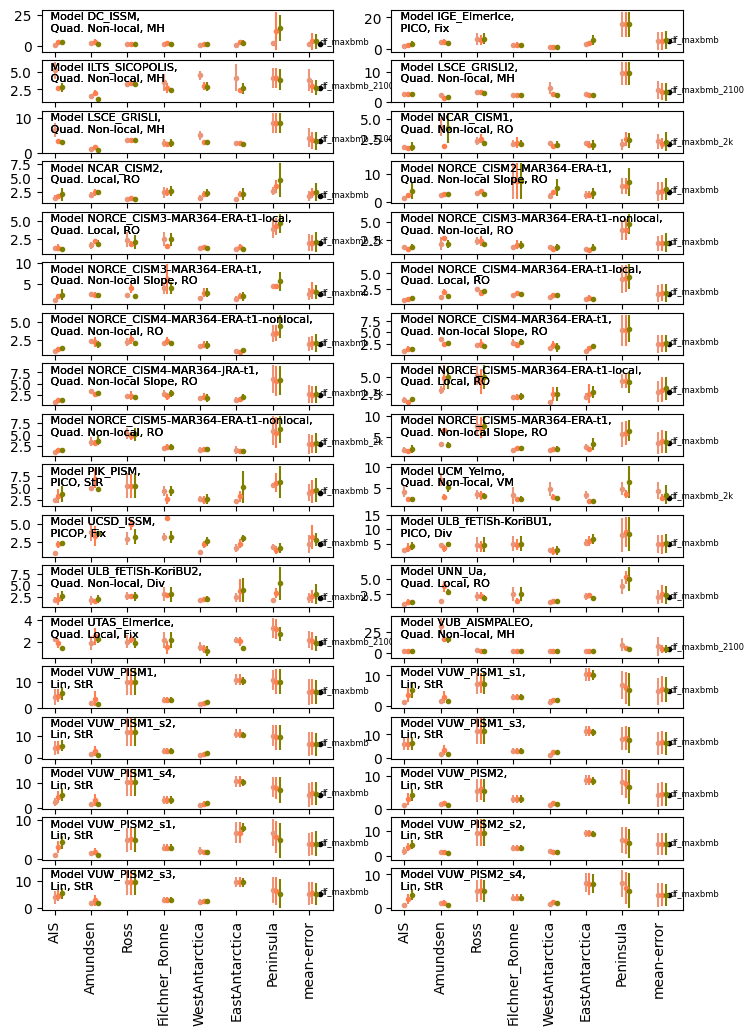

In [20]:
a4_width = 8.27  # inches
a4_height = 11.69
fs = 8
f, ax2 = plt.subplots(int(len(models)/2),2,figsize = (a4_width,a4_height),sharex = True)
for l,df in enumerate(dfs):
    df_ms = df_ms_all[l].copy()
    df_ms_n = df_ms_n_all[l].copy()
    
   
    for i,Mod in enumerate(models):
        best = 1e15
        dfmodel = df[df['Model']== Mod]
        df_ms_model = df_ms[df_ms['Model']== Mod]
        df_ms_n_model =df_ms_n[df_ms_n['Model']== Mod] 
        
       
        for j,region in enumerate(regions):
            mn =np.nanmean(dfmodel[f'{region}'].values).copy()
            std =np.nanstd(dfmodel[f'{region}'].values).copy()
                
                
            ax = ax2[i//2,i%2]
            ax.errorbar(j+l*0.1, mn, std, linestyle='None', marker='.',color = colors2[l])
        if Mod == 'VUW_PISM1_s1':
            mn =np.nanmean(dfmodel[regions].values[1:]).copy()
            std =np.nanstd(dfmodel[regions].values[1:]).copy()
        else:
            mn =np.nanmean(dfmodel[regions].values).copy()
            std =np.nanstd(dfmodel[regions].values).copy()
        ax.errorbar(j+1+l*0.1, mn, std, linestyle='None', marker='.',color = colors2[l])
        df_best.iloc[i,1] = np.min([df_best.iloc[i,1],mn]).copy()
        if df_best.iloc[i,1] == mn:
            df_best.iloc[i,2]=dfs_string[l]
            # get ms woth same method for all regions
            for region in regions:
                
                if Mod == 'VUW_PISM1_s1':
                    df_best[f'melt_sensetivity_{region}'].iloc[i]=np.nanmean(df_ms_model[region].values[1:]).copy()
                    df_best[f'melt_sensetivity_intercept_{region}'].iloc[i]=np.nanmean(df_ms_n_model[region].values[1:]).copy()
                
                else:
                    df_best[f'melt_sensetivity_{region}'].iloc[i]=np.nanmean(df_ms_model[region].values).copy()
                    df_best[f'melt_sensetivity_intercept_{region}'].iloc[i]=np.nanmean(df_ms_n_model[region].values).copy()
            
            
        df_info_model = df_info[df_info['fileID']==df.iloc[i].Model ]
        df_info_model_exp = df_info_model[df_info_model['Experiment']==experiments[0]]
        meltparam =  df_info_model_exp['Melt parameterisation'].values[0]
        df_best.iloc[i,3]= meltparam
        
        icefront =  df_info_model_exp['ice front'].values[0]
        ax.text(0.02, 0.98,f' Model {Mod},\n {meltparam}, {icefront} ',transform=ax.transAxes,fontsize = fs, va='top',color = 'black')

#                 ax.scatter(j,dfmodel[f'{region}'].values,color = colors[k],marker = scatters[l])
#                 ax.set_title(f'{region}')
for i in range(df_best.shape[0]):
    ax = ax2[i//2,i%2]
    ax.scatter(j+1+3*0.1,df_best.iloc[i,1],color = 'black',marker='.')
    ax.text(j+1+3*0.1,df_best.iloc[i,1],df_best.iloc[i,2] ,fontsize = 6)
ax = ax2[i//2,i%2]
regions_all.append('mean-error')

ax.set_xticks(np.arange(len(regions_all))  )
ax.set_xticklabels(regions_all, rotation=90)
ax = ax2[i//2,0]
 
ax.set_xticks(np.arange(len(regions_all))  )

ax.set_xticklabels(regions_all, rotation=90)
df_best.to_csv('tables/best_groundingline_ms_method_per_model.csv')

# ax2[0].text(0.3,1,'for maxBMB',transform=ax2[0].transAxes,fontsize = 15)

In [21]:
df_best



,Model,mean-error,method,parameterization,melt_sensetivity_AIS,melt_sensetivity_intercept_AIS,melt_sensetivity_Amundsen,melt_sensetivity_intercept_Amundsen,melt_sensetivity_Ross,melt_sensetivity_intercept_Ross,melt_sensetivity_Filchner_Ronne,melt_sensetivity_intercept_Filchner_Ronne,melt_sensetivity_WestAntarctica,melt_sensetivity_intercept_WestAntarctica,melt_sensetivity_EastAntarctica,melt_sensetivity_intercept_EastAntarctica,melt_sensetivity_Peninsula,melt_sensetivity_intercept_Peninsula
0,DC_ISSM,1.853524,df_maxbmb,Quad. Non-local,0.279796,0.060907,0.288132,1.054022,0.334822,-0.186864,0.367383,-0.038477,0.329251,0.011838,0.318088,0.024222,0.117871,0.117242
1,IGE_ElmerIce,5.124112,df_maxbmb,PICO,0.555169,0.241474,0.250569,2.081113,0.737996,-0.196261,0.618789,-0.364427,0.422812,0.355278,0.896206,-0.030202,1.226679,-0.583978
2,ILTS_SICOPOLIS,2.712475,df_maxbmb_2100,Quad. Non-local,0.798253,-0.363560,1.640232,-0.306777,0.516820,-0.271055,0.618669,-0.318878,0.741188,-0.280469,0.798360,-0.332787,0.621974,-0.449947
3,LSCE_GRISLI2,3.440019,df_maxbmb_2100,Quad. Non-local,0.372984,-0.191822,0.756686,-0.098807,0.252829,-0.146321,0.296752,-0.159205,0.323395,-0.138282,0.362562,-0.147512,0.341632,-0.308723
4,LSCE_GRISLI,3.508889,df_maxbmb_2100,Quad. Non-local,0.399157,-0.222417,0.790564,-0.154721,0.265364,-0.158891,0.310195,-0.167951,0.326860,-0.154177,0.360366,-0.151074,0.276966,-0.230111
5,NCAR_CISM1,1.894577,df_maxbmb_2k,Quad. Non-local,0.598076,-0.231648,0.998707,-1.206391,0.682192,-0.472126,0.950360,-0.569910,0.691433,-0.301333,0.584167,-0.236883,0.305044,0.091967
6,NCAR_CISM2,1.767217,df_maxbmb,Quad. Local,1.229462,-0.404258,1.850484,-1.657088,1.184411,-0.354836,2.105905,-0.922383,1.568962,-0.728606,1.091191,-0.159608,0.372645,0.124263
7,NORCE_CISM2-MAR364-ERA-t1,3.636297,df_maxbmb,Quad. Non-local Slope,1.334803,-0.553924,2.690585,-3.165239,1.619932,-1.127289,3.417316,-2.342774,1.827122,-1.037523,1.468488,-0.507378,0.518418,-0.216420
8,NORCE_CISM3-MAR364-ERA-t1-local,1.924737,df_maxbmb_2k,Quad. Local,0.184921,-0.057338,0.191351,0.007064,0.239244,-0.118299,0.402137,-0.233792,0.238463,-0.085903,0.176983,-0.047710,0.144019,-0.055561
9,NORCE_CISM3-MAR364-ERA-t1-nonlocal,1.999465,df_maxbmb,Quad. Non-local,0.219580,-0.109879,0.296078,-0.202942,0.254642,-0.191009,0.307179,-0.142307,0.274420,-0.165842,0.209810,-0.076827,0.132571,-0.040842


### Group by AIS -, regions-mean (amundesen,FRIS,ROSS) and EAST,WEST ) module score


In [22]:
index =np.argsort(df_best['mean-error'].values)
df_area_change_all = pd.read_csv('tables/precentage_change_ofIceShelf.csv')
p_change = np.zeros(len(index))
for i,Model in enumerate(df_best['Model'].values[index]):
    df = df_area_change_all[df_area_change_all['Model']==Model]
    p_change[i] = np.nanmean(df.AIS.values)

In [10]:
df_area_change_all 

,Experiment,Model,Path,sector_1,sector_2,sector_3,sector_4,sector_5,sector_6,sector_7,...,sector_13,sector_14,sector_15,sector_16,sector_17,sector_18,AIS,region_1,region_2,region_3
0,expAE02,DC_ISSM,/Volumes/CrucialX8/computing/data/antarctica/i...,-62.806660,-59.405321,-26.742345,14.345434,-55.592716,-92.392045,67.803127,...,-39.224315,-62.454599,-78.437471,-73.293954,-93.082607,-72.541356,-64.142507,-54.309064,-70.054489,-79.649842
1,expAE02,IGE_ElmerIce,/Volumes/CrucialX8/computing/data/antarctica/i...,-83.855385,-7.077341,-77.437353,-15.459472,-20.458217,-21.260700,75.276494,...,-77.352357,-87.076432,-91.275126,-93.609065,-96.968937,-84.004158,-42.084348,-20.652670,-52.876216,-91.231948
2,expAE02,ILTS_SICOPOLIS,/Volumes/CrucialX8/computing/data/antarctica/i...,-92.000586,-41.758871,-96.369940,41.980022,-75.543743,-98.519492,-29.492447,...,-98.383528,-73.261541,-88.753426,-93.581790,-99.834549,-91.983527,-74.314314,-57.328421,-86.532390,-95.319247
3,expAE02,LSCE_GRISLI2,/Volumes/CrucialX8/computing/data/antarctica/i...,-95.522547,-82.101059,-95.494527,-77.981144,-85.705668,-99.430501,-78.791553,...,-89.115560,-96.293670,-97.101194,-95.968366,-100.000000,-98.906577,-91.699320,-85.241902,-96.282947,-98.561305
4,expAE02,LSCE_GRISLI,/Volumes/CrucialX8/computing/data/antarctica/i...,-99.156499,-92.681539,-98.916018,238.743353,-96.231961,-99.777299,-85.280496,...,-90.205890,-88.844448,-95.921522,-96.083272,-100.000000,-99.392277,-93.883264,-89.904976,-96.716613,-98.743415
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,expAE05,VUW_PISM2,/Volumes/CrucialX8/computing/data/antarctica/i...,-99.767488,-67.502260,-79.362768,178.333497,-92.114991,-93.904412,18.647234,...,-53.601652,-13.896975,-73.480165,-84.946263,-86.082393,-55.874002,-69.432080,-69.270736,-69.132835,-72.861326
140,expAE05,VUW_PISM2_s1,/Volumes/CrucialX8/computing/data/antarctica/i...,-99.298817,-67.894357,-82.453471,126.320493,-92.220271,-94.139886,0.595658,...,-53.466821,-5.309983,-72.652930,-85.003084,-87.369865,-61.612964,-69.300407,-71.790814,-66.343123,-75.713718
141,expAE05,VUW_PISM2_s2,/Volumes/CrucialX8/computing/data/antarctica/i...,-99.535125,-75.139844,-74.685937,114.448452,-91.463268,-94.296718,32.716918,...,-58.284158,-18.553370,-72.627103,-84.644878,-81.951278,-70.206177,-73.279655,-74.742502,-71.496612,-77.414799
142,expAE05,VUW_PISM2_s3,/Volumes/CrucialX8/computing/data/antarctica/i...,-97.682124,-76.494533,-69.029957,-34.143403,-91.645288,-94.133580,25.843129,...,-56.309754,-22.566107,-73.946387,-83.080894,-82.087052,-71.895963,-75.833559,-81.445658,-70.740986,-77.901971


Text(0, 0.5, 'Melt sensetivity')

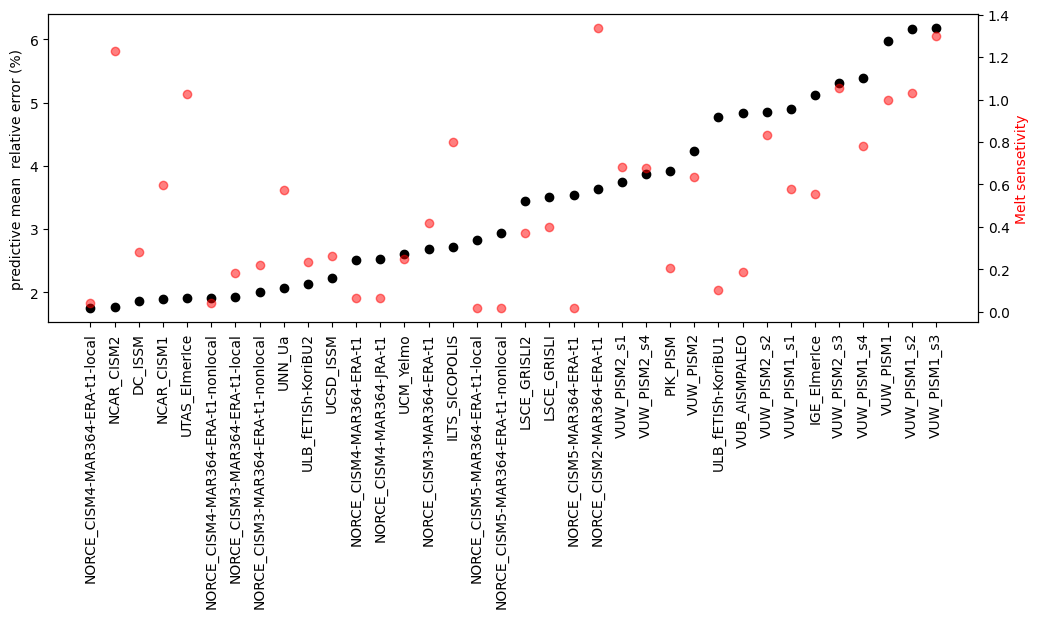

In [23]:
f,ax = plt.subplots(1,1,figsize =(12,4))
ax2 = ax.twinx()
ax.scatter(np.arange(len(index)),df_best['mean-error'].values[index],color = 'black')
# for i in range(len(index)):
#     ax.annotate(df_best['parameterization'].values[index][i],(i,df_best['mean-error'].values[index][i]),rotation = 90)


ax.set_xticks(np.arange(len(index)))
ax.set_xticklabels(df_best['Model'].values[index], rotation = 90)
ax.set_ylabel('predictive mean  relative error (%)')
ax2.scatter(np.arange(len(index)),df_best['melt_sensetivity_AIS'].values[index], color = 'red',alpha =  0.5)
# 
ax2.set_ylabel('Melt sensetivity',color = 'red')



## melt sensetivity

In [24]:
index =np.argsort(df_best['melt_sensetivity_AIS'].values)
# df_area_change_all = pd.read_csv('tables/precentage_change_ofIceShelf.csv')
# p_change = np.zeros(len(index))
# for i,Model in enumerate(df_best['Model'].values[index]):
#     df = df_area_change_all[df_area_change_all['Model']==Model]
#     p_change[i] = np.nanmean(df.AIS.values)

Text(0, 0.5, 'groundingline Melt sensetivity')

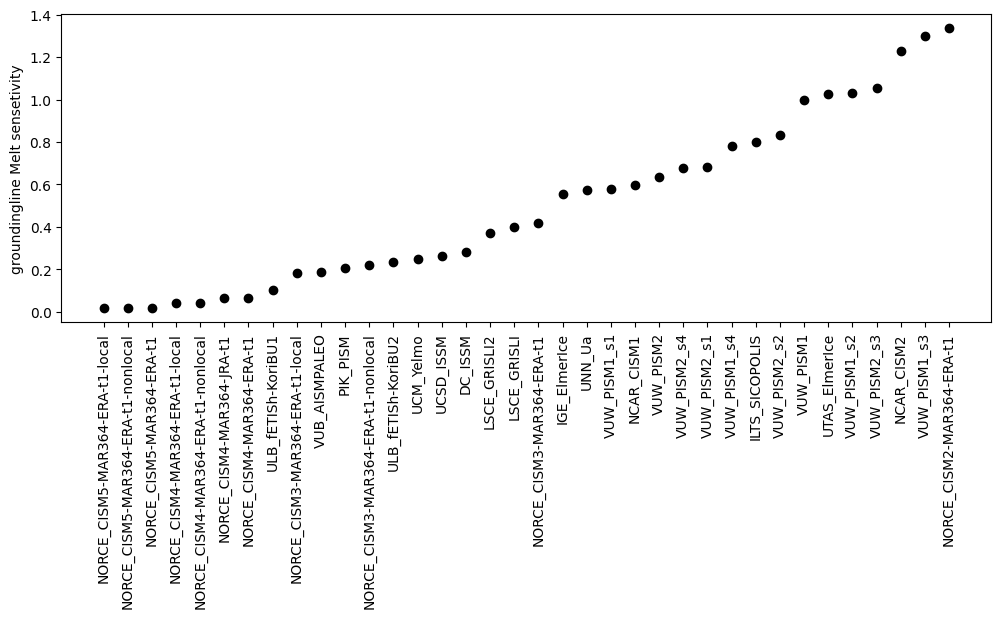

In [26]:
f,ax = plt.subplots(1,1,figsize =(12,4))
# ax2 = ax.twinx()
ax.scatter(np.arange(len(index)),df_best['melt_sensetivity_AIS'].values[index],color = 'black')
# for i in range(len(index)):
#     ax.annotate(df_best['parameterization'].values[index][i],(i,df_best['mean-error'].values[index][i]),rotation = 90)


ax.set_xticks(np.arange(len(index)))
ax.set_xticklabels(df_best['Model'].values[index], rotation = 90)
ax.set_ylabel('groundingline Melt sensetivity')
# ax2.scatter(np.arange(len(index)),df_best['melt_sensetivity_AIS'].values[index], color = 'red',alpha =  0.5)
# # 
# ax2.set_ylabel('Melt sensetivity',color = 'red')


In [12]:
mask = df_best.method.values == df_best2.method.values
df_best2.Model.values[~mask]

array(['DC_ISSM', 'IGE_ElmerIce', 'ILTS_SICOPOLIS', 'LSCE_GRISLI2',
       'LSCE_GRISLI', 'NCAR_CISM1', 'NCAR_CISM2',
       'NORCE_CISM2-MAR364-ERA-t1', 'NORCE_CISM3-MAR364-ERA-t1-local',
       'NORCE_CISM3-MAR364-ERA-t1-nonlocal', 'NORCE_CISM3-MAR364-ERA-t1',
       'NORCE_CISM4-MAR364-ERA-t1-local',
       'NORCE_CISM4-MAR364-ERA-t1-nonlocal', 'NORCE_CISM4-MAR364-ERA-t1',
       'NORCE_CISM4-MAR364-JRA-t1', 'NORCE_CISM5-MAR364-ERA-t1-local',
       'NORCE_CISM5-MAR364-ERA-t1-nonlocal', 'NORCE_CISM5-MAR364-ERA-t1',
       'PIK_PISM', 'UCM_Yelmo', 'UCSD_ISSM', 'ULB_fETISh-KoriBU1',
       'ULB_fETISh-KoriBU2', 'UNN_Ua', 'UTAS_ElmerIce', 'VUB_AISMPALEO',
       'VUW_PISM1', 'VUW_PISM1_s1', 'VUW_PISM1_s2', 'VUW_PISM1_s3',
       'VUW_PISM1_s4', 'VUW_PISM2', 'VUW_PISM2_s1', 'VUW_PISM2_s2',
       'VUW_PISM2_s3', 'VUW_PISM2_s4'], dtype=object)

In [13]:
df_best2.method.values[~mask]

array(['nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan',
       'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan',
       'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan',
       'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan'],
      dtype=object)

In [14]:
df_best2

,Model,mean-error,method,parameterization,melt_sensetivity_AIS,melt_sensetivity_intercept_AIS,melt_sensetivity_Amundsen,melt_sensetivity_intercept_Amundsen,melt_sensetivity_Ross,melt_sensetivity_intercept_Ross,melt_sensetivity_Filchner_Ronne,melt_sensetivity_intercept_Filchner_Ronne,melt_sensetivity_WestAntarctica,melt_sensetivity_intercept_WestAntarctica,melt_sensetivity_EastAntarctica,melt_sensetivity_intercept_EastAntarctica,melt_sensetivity_Peninsula,melt_sensetivity_intercept_Peninsula
0,DC_ISSM,1.000000e+15,nan,nan,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,IGE_ElmerIce,1.000000e+15,nan,nan,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,ILTS_SICOPOLIS,1.000000e+15,nan,nan,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,LSCE_GRISLI2,1.000000e+15,nan,nan,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,LSCE_GRISLI,1.000000e+15,nan,nan,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,NCAR_CISM1,1.000000e+15,nan,nan,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,NCAR_CISM2,1.000000e+15,nan,nan,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,NORCE_CISM2-MAR364-ERA-t1,1.000000e+15,nan,nan,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,NORCE_CISM3-MAR364-ERA-t1-local,1.000000e+15,nan,nan,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,NORCE_CISM3-MAR364-ERA-t1-nonlocal,1.000000e+15,nan,nan,0,0,0,0,0,0,0,0,0,0,0,0,0,0


### Which method lincomb or overall MS???

In [ ]:
regions2 = ['Ross', 'FilchnerRonne']
colors2 = ['darksalmon','coral','olive','yellow','cyan','steelblue']

dfs2 =  [df_maxbmb,df_maxbmb_2k,df_maxbmb_2100,df_maxbmb_lc,df_maxbmb_2k_lc,df_maxbmb_2100_lc,]